In [1]:
import pandas as pd

# Load the credit card transaction dataset
df = pd.read_csv("C:\\Users\\hp\\Desktop\\Project_CSV(ML)\\creditcard.csv")

In [2]:
df.shape

(284807, 31)

In [3]:
print(df.isnull().sum().sum())

0


In [4]:
print(df['Class'].value_counts())


Class
0    284315
1       492
Name: count, dtype: int64


In [5]:
print("\n⚠️ Fraud Percentage:", 
      round(df['Class'].mean() * 100, 4), "%")


⚠️ Fraud Percentage: 0.1727 %


In [6]:
print("\n💰 Amount Statistics:")
print(df['Amount'].describe())


💰 Amount Statistics:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [7]:

# Dataset dimensions
print("📊 Shape:", df.shape)

# Check for any missing values
print("\n❓ Missing Values:")
print(df.isnull().sum().sum())

# Count of Fraud vs Genuine transactions
print("\n🔍 Class Distribution:")
print(df['Class'].value_counts())

# What percentage of transactions are fraudulent?
print("\n⚠️ Fraud Percentage:", 
      round(df['Class'].mean() * 100, 4), "%")

# Basic statistics of transaction amounts
print("\n💰 Amount Statistics:")
print(df['Amount'].describe())

📊 Shape: (284807, 31)

❓ Missing Values:
0

🔍 Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

⚠️ Fraud Percentage: 0.1727 %

💰 Amount Statistics:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


# EDA Process Start


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
plt.style.use('seaborn-v0_8')

In [10]:
print("✅ Libraries ready!")
print("✅ Data loaded!")

✅ Libraries ready!
✅ Data loaded!


In [11]:
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Graph 1 → How many Fraud vs Genuine? (Class Distribution)


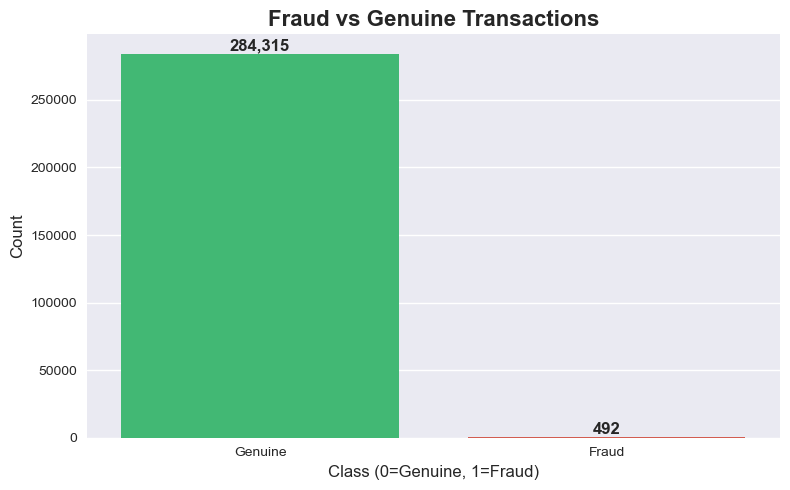


Genuine: 284,315
Fraud:   492
Ratio:   577:1


In [12]:
plt.figure(figsize=(8, 5))

# Create Count Plot
ax = sns.countplot(x='Class', data=df,
                   hue='Class',
                   palette={0: '#2ecc71', 1: '#e74c3c'},
                   legend=False)

# Axis labels and title
plt.title('Fraud vs Genuine Transactions', 
          fontsize=16, fontweight='bold')
plt.xlabel('Class (0=Genuine, 1=Fraud)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['Genuine', 'Fraud'])

# Display count on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., 
                 p.get_height()),
                ha='center', va='bottom', 
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nGenuine: {df[df['Class']==0].shape[0]:,}")
print(f"Fraud:   {df[df['Class']==1].shape[0]:,}")
print(f"Ratio:   {df[df['Class']==0].shape[0] // df[df['Class']==1].shape[0]}:1")

# On Which Time Fraud Exist

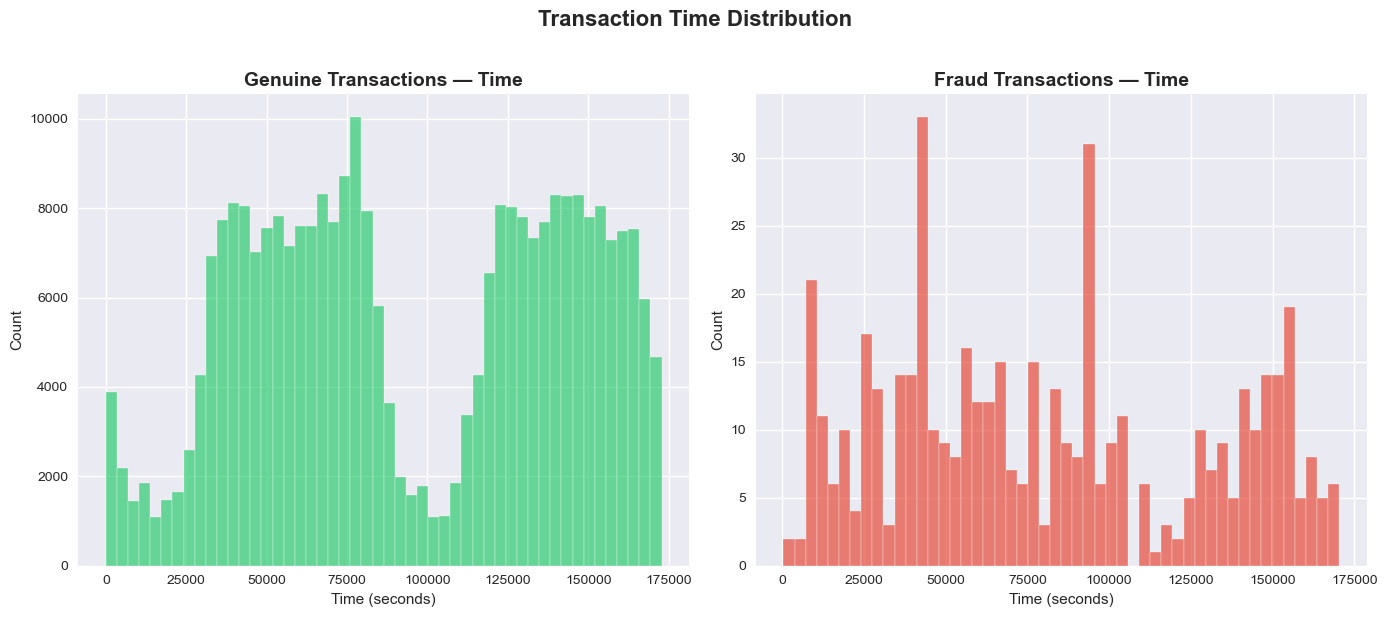

In [13]:
plt.figure(figsize=(14, 6))

# Genuine transactions — Time distribution
plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
plt.hist(df[df['Class']==0]['Time'], 
         bins=50, 
         color='#2ecc71', 
         alpha=0.7,
         edgecolor='white')
plt.title('Genuine Transactions — Time', 
          fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=11)
plt.ylabel('Count', fontsize=11)

# Fraud transactions — Time distribution
plt.subplot(1, 2, 2)  # 1 row, 2 columns, second plot
plt.hist(df[df['Class']==1]['Time'], 
         bins=50, 
         color='#e74c3c', 
         alpha=0.7,
         edgecolor='white')
plt.title('Fraud Transactions — Time', 
          fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=11)
plt.ylabel('Count', fontsize=11)

plt.suptitle('Transaction Time Distribution', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Amount vs Fraud

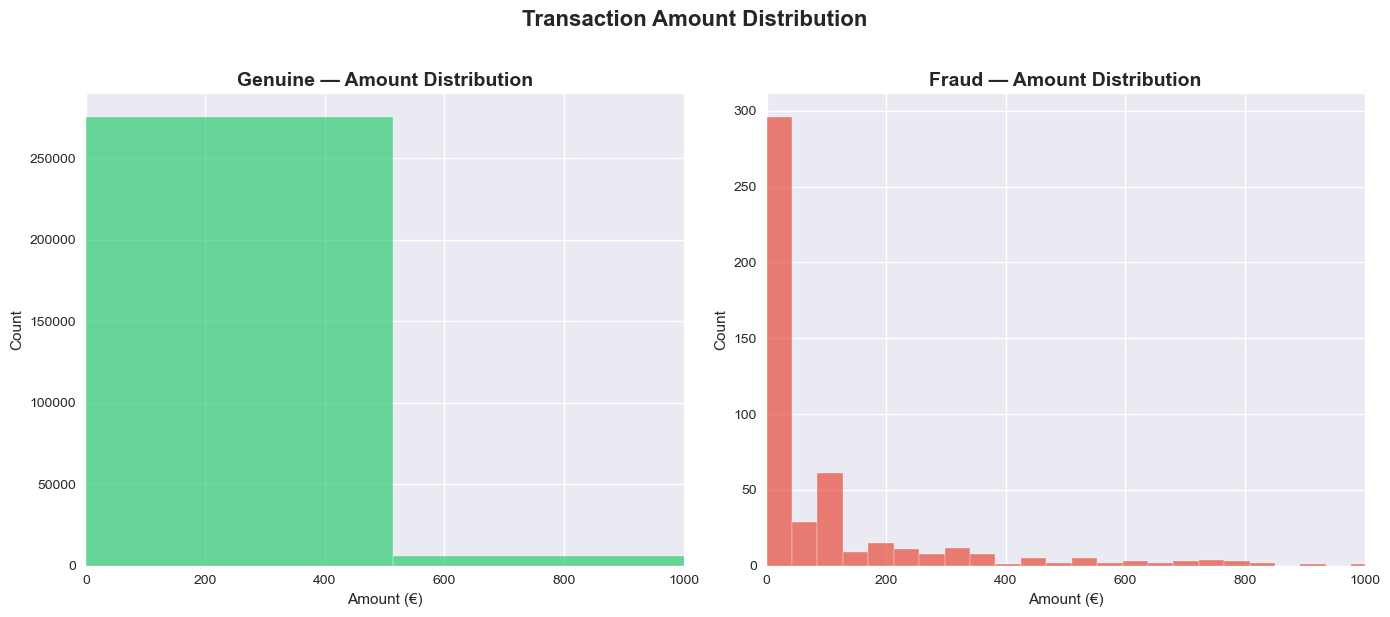

💰 Genuine Amount Stats:
count    284315.00
mean         88.29
std         250.11
min           0.00
25%           5.65
50%          22.00
75%          77.05
max       25691.16
Name: Amount, dtype: float64

🚨 Fraud Amount Stats:
count     492.00
mean      122.21
std       256.68
min         0.00
25%         1.00
50%         9.25
75%       105.89
max      2125.87
Name: Amount, dtype: float64


In [14]:
plt.figure(figsize=(14, 6))

# Genuine transaction amounts
plt.subplot(1, 2, 1)
plt.hist(df[df['Class']==0]['Amount'], 
         bins=50, 
         color='#2ecc71', 
         alpha=0.7,
         edgecolor='white')
plt.title('Genuine — Amount Distribution', 
          fontsize=14, fontweight='bold')
plt.xlabel('Amount (€)', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.xlim(0, 1000)  # Zoom in to €0–1000 range

# Fraud transaction amounts
plt.subplot(1, 2, 2)
plt.hist(df[df['Class']==1]['Amount'], 
         bins=50, 
         color='#e74c3c', 
         alpha=0.7,
         edgecolor='white')
plt.title('Fraud — Amount Distribution', 
          fontsize=14, fontweight='bold')
plt.xlabel('Amount (€)', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.xlim(0, 1000)

plt.suptitle('Transaction Amount Distribution', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary statistics for both classes
print("💰 Genuine Amount Stats:")
print(df[df['Class']==0]['Amount'].describe().round(2))
print("\n🚨 Fraud Amount Stats:")
print(df[df['Class']==1]['Amount'].describe().round(2))

# Fraud vs Genuine

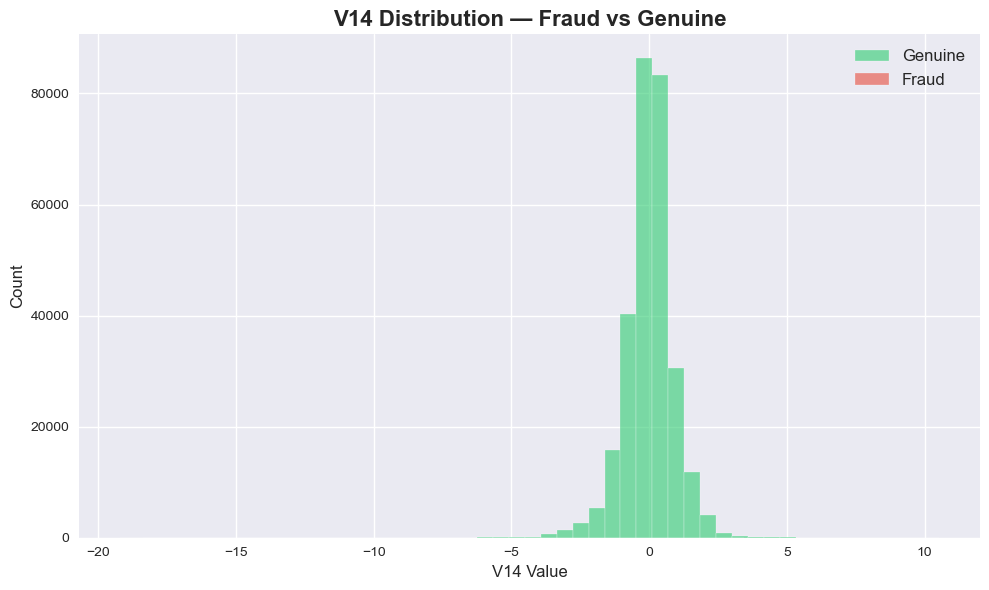

✅ Genuine V14 Stats:
count    284315.00
mean          0.01
std           0.90
min         -18.39
25%          -0.42
50%           0.05
75%           0.49
max          10.53
Name: V14, dtype: float64

🚨 Fraud V14 Stats:
count    492.00
mean      -6.97
std        4.28
min      -19.21
25%       -9.69
50%       -6.73
75%       -4.28
max        3.44
Name: V14, dtype: float64


In [15]:
plt.figure(figsize=(10, 6))

# Genuine — V14 distribution
plt.hist(df[df['Class']==0]['V14'],
         bins=50,
         color='#2ecc71',
         alpha=0.6,
         label='Genuine',
         edgecolor='white')

# Fraud — V14 distribution
plt.hist(df[df['Class']==1]['V14'],
         bins=50,
         color='#e74c3c',
         alpha=0.6,
         label='Fraud',
         edgecolor='white')

plt.title('V14 Distribution — Fraud vs Genuine',
          fontsize=16, fontweight='bold')
plt.xlabel('V14 Value', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Summary statistics for V14 by class
print("✅ Genuine V14 Stats:")
print(df[df['Class']==0]['V14'].describe().round(2))
print("\n🚨 Fraud V14 Stats:")
print(df[df['Class']==1]['V14'].describe().round(2))

# Why the Red (Fraud) Was Invisible in the Combined Graph — and Why We Split It

In the combined graph above, the red Fraud bars were completely hidden. Here is the reason and the fix:

**Combined Graph (overlapping):**
- Both classes share the same Y-axis
- Genuine = 284,315 transactions vs Fraud = 492 transactions
- The scale difference (~577:1) makes Fraud bars invisible even though they exist

**Separate Subplots:**
- Each class gets its own independent Y-axis
- Every distribution is clearly visible
- Comparison becomes straightforward

**Key Insight:** This is a direct consequence of **class imbalance** — a core challenge in fraud detection datasets.

**When to use combined vs. separate plots:**
- **Combined** → Useful when both classes have similar counts (balanced dataset)
- **Separate** → Necessary when one class is a tiny minority (imbalanced dataset like this one)

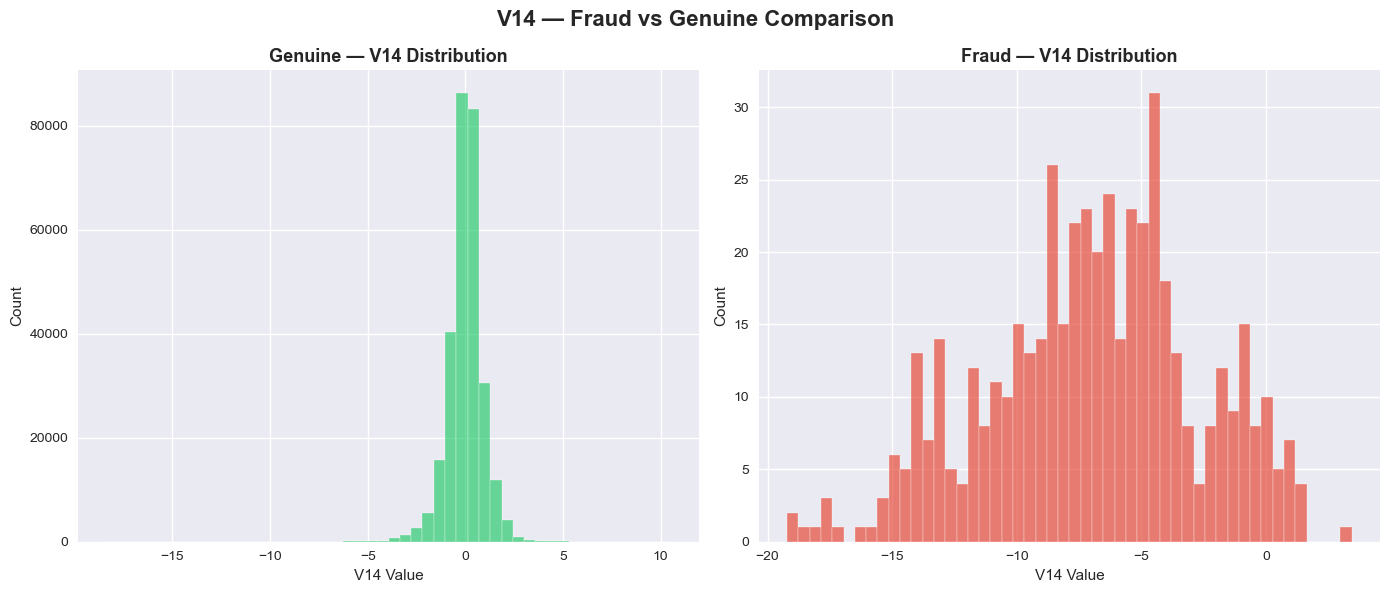

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left subplot — Genuine V14 distribution
axes[0].hist(df[df['Class']==0]['V14'],
             bins=50,
             color='#2ecc71',
             alpha=0.7,
             edgecolor='white')
axes[0].set_title('Genuine — V14 Distribution',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('V14 Value', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)

# Right subplot — Fraud V14 distribution
axes[1].hist(df[df['Class']==1]['V14'],
             bins=50,
             color='#e74c3c',
             alpha=0.7,
             edgecolor='white')
axes[1].set_title('Fraud — V14 Distribution',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('V14 Value', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)

plt.suptitle('V14 — Fraud vs Genuine Comparison',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

'''
In the COMBINED graph:
Red (Fraud) was completely invisible!

In the SEPARATE graphs:
Fraud V14 ranges from -20 to 0
Genuine V14 ranges from  -5 to +5

So the overlap should be between -5 and 0!
Then why was red invisible in the combined plot?

Answer: 
  Combined graph  → Shared Y-axis
                    Small-count values get HIDDEN
                    when the scale difference is huge!

  Separate graphs → Independent Y-axis per class
                    Everything is CLEARLY visible
                    Comparison becomes easy!
'''

# Recruiter Question
"What challenge did you face during visualization?"

**Answer:** "Due to class imbalance, fraud transactions were invisible on the same graph — the scale difference of 492 vs 284,315 was too large. I used separate subplots so that the fraud distribution could be seen clearly."

**Why this matters to a recruiter:**
- Shows awareness of **class imbalance** (a real-world problem)
- Demonstrates **visualization decision-making** (not just plotting blindly)
- Proves you understand *why* a chart looks the way it does

# How We Identified the Key Columns — V12, V14, V17

Three approaches were used to select the most important features:

1. **Research Paper** — The original dataset authors (ULB Machine Learning Group) highlighted these features in their published paper
2. **Correlation Heatmap** — Computed the absolute correlation of every V-feature with the target `Class` column
3. **Distribution Graphs** — Plotted each V-feature for Fraud vs Genuine to visually confirm clear separation

All three approaches agreed on the same top features, giving us **high confidence** in the selection.

**Why not use all 28 V-features?**
More features ≠ better model. Irrelevant features add noise, slow training, and can hurt generalisation (curse of dimensionality). Selecting the most correlated features is a standard dimensionality-reduction step.

**Why not apply PCA again?**
PCA was already applied by the dataset creators to generate the V1–V28 features (to protect cardholder privacy). Applying PCA again would be redundant.

In [18]:
# Compute correlation of every feature with the target (Class)
correlations = df.corr()['Class'].drop('Class')

# Sort by absolute correlation — strongest relationship first
correlations_sorted = correlations.abs().sort_values(
                      ascending=False)

print("🔍 Top 10 Important Features:")
print(correlations_sorted.head(10).round(3))

🔍 Top 10 Important Features:
V17    0.326
V14    0.303
V12    0.261
V10    0.217
V16    0.197
V3     0.193
V7     0.187
V11    0.155
V4     0.133
V18    0.111
Name: Class, dtype: float64


In [19]:
# The feature at the top has the highest correlation with fraud.
# Features lower in the list have progressively weaker relationships.
# We focus on the top features for visualisation and model training.

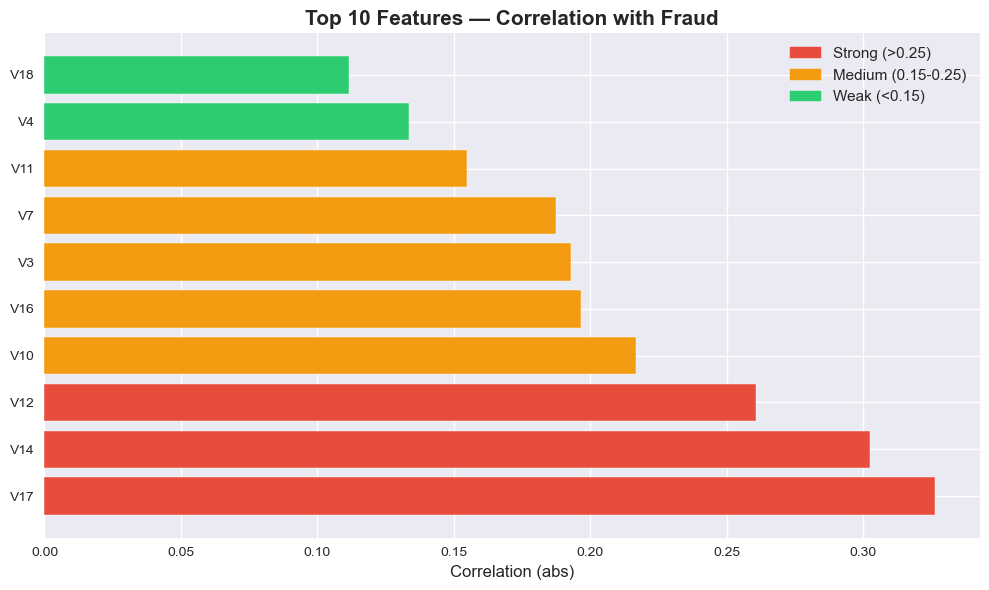

In [20]:
plt.figure(figsize=(10, 6))

# Take top 10 most correlated features
top_features = correlations_sorted.head(10)

# Assign colours based on correlation strength
colors = ['#e74c3c' if x > 0.25 
          else '#f39c12' if x > 0.15 
          else '#2ecc71' 
          for x in top_features.values]

plt.barh(top_features.index, 
         top_features.values,
         color=colors,
         edgecolor='white')

plt.title('Top 10 Features — Correlation with Fraud',
          fontsize=15, fontweight='bold')
plt.xlabel('Correlation (abs)', fontsize=12)

# Legend showing colour thresholds
from matplotlib.patches import Patch

legend = [
    Patch(color='#e74c3c', label='Strong (>0.25)'),
    Patch(color='#f39c12', label='Medium (0.15-0.25)'),
    Patch(color='#2ecc71', label='Weak (<0.15)')
]
plt.legend(handles=legend, fontsize=11)

plt.tight_layout()
plt.show()

# Train/Split

In [21]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target label (y)
X = df.drop('Class', axis=1)   # All columns EXCEPT Class
y = df['Class']                # Only the Class column

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% held out for testing
    random_state=42,      # Ensures reproducibility
    stratify=y             # Maintains the fraud ratio in both splits
)

print("✅ Split Complete!")
print(f"Training samples: {X_train.shape[0]:,}")
print(f"Testing samples:  {X_test.shape[0]:,}")

print(f"\n📊 Fraud in Training set: {y_train.sum()}")
print(f"📊 Fraud in Testing set:  {y_test.sum()}")

✅ Split Complete!
Training samples: 227,845
Testing samples:  56,962

📊 Training set mein Fraud: 394
📊 Testing set mein Fraud:  98


# Scale Parameters 

In [22]:
from sklearn.preprocessing import StandardScaler

# Separate scalers for Amount and Time — fitted independently
amount_scaler = StandardScaler()
time_scaler = StandardScaler()

# Training data — FIT then TRANSFORM (learns mean & std from training data)
X_train['Amount'] = amount_scaler.fit_transform(X_train[['Amount']])
X_train['Time'] = time_scaler.fit_transform(X_train[['Time']])

# Test data — TRANSFORM ONLY (applies the same mean & std from training)
# Never fit on test data — that would cause data leakage!
X_test['Amount'] = amount_scaler.transform(X_test[['Amount']])
X_test['Time'] = time_scaler.transform(X_test[['Time']])

print("✅ Scaling Complete!")
print("\nTraining Amount stats (scaled):")
print(X_train['Amount'].describe().round(2))

print("\nTraining Time stats (scaled):")
print(X_train['Time'].describe().round(2))

✅ Scaling Complete!

Training Amount stats (scaled):
count    227845.00
mean         -0.00
std           1.00
min          -0.35
25%          -0.33
50%          -0.26
75%          -0.04
max         102.12
Name: Amount, dtype: float64

Training Time stats (scaled):
count    227845.00
mean         -0.00
std           1.00
min          -2.00
25%          -0.86
50%          -0.21
75%           0.94
max           1.64
Name: Time, dtype: float64


# Applying SMOTE

In [23]:
from imblearn.over_sampling import SMOTE

# Initialise SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE ONLY on training data — never on test data!
# Applying SMOTE on test data would give an unrealistically optimistic evaluation.
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("✅ SMOTE Applied!")
print(f"\n📊 BEFORE SMOTE:")
print(f"Genuine: {(y_train==0).sum():,}")
print(f"Fraud:   {(y_train==1).sum():,}")

print(f"\n📊 AFTER SMOTE:")
print(f"Genuine: {(y_train_smote==0).sum():,}")
print(f"Fraud:   {(y_train_smote==1).sum():,}")

print(f"\n🔢 New Training Size: {X_train_smote.shape[0]:,}")

✅ SMOTE Applied!

📊 BEFORE SMOTE:
Genuine: 227,451
Fraud:   394

📊 AFTER SMOTE:
Genuine: 227,451
Fraud:   227,451

🔢 New Training Size: 454,902


# Model 1 — Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initialise the model
log_model = LogisticRegression(random_state=42, max_iter=1000)

# Train on SMOTE-balanced data
log_model.fit(X_train_smote, y_train_smote)

# Predict on ORIGINAL test data (not SMOTE — real-world distribution)
y_pred_log = log_model.predict(X_test)

print("✅ Logistic Regression Trained!")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_log, 
                            target_names=['Genuine', 'Fraud']))

✅ Logistic Regression Trained!

📊 Classification Report:
              precision    recall  f1-score   support

     Genuine       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Initialise XGBoost
# scale_pos_weight: tells the model to give extra importance to the minority (fraud) class
# Formula: Genuine count / Fraud count = 227451 / 394 ≈ 577
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',     # Error metric used during training
    scale_pos_weight=577        # Give 577x more weight to the Fraud class
)

# Train on SMOTE-balanced data
xgb_model.fit(X_train_smote, y_train_smote)

# Predict on original test data
y_pred_xgb = xgb_model.predict(X_test)

print("✅ XGBoost Trained!")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_xgb, 
                            target_names=['Genuine', 'Fraud']))

✅ XGBoost Trained!

📊 Classification Report:
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56864
       Fraud       0.49      0.88      0.63        98

    accuracy                           1.00     56962
   macro avg       0.74      0.94      0.81     56962
weighted avg       1.00      1.00      1.00     56962



# Model 2 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,        # 100 decision trees
    class_weight='balanced', # Automatically handles class imbalance
    n_jobs=-1                # Use all CPU cores (parallel training)
)

rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test)

print("✅ Random Forest Trained!")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_rf,
                            target_names=['Genuine', 'Fraud']))

# Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix for Random Forest (our best model)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, 
            annot=True,          # Show numbers inside each cell
            fmt='d',              # Display as integers (not decimals)
            cmap='Blues',          # Colour theme
            xticklabels=['Genuine', 'Fraud'],
            yticklabels=['Genuine', 'Fraud'])

plt.title('Confusion Matrix — Random Forest', 
          fontsize=15, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

# Break down each cell in the confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"✅ True Negative  (Genuine correctly identified): {tn:,}")
print(f"❌ False Positive (Genuine wrongly flagged as Fraud): {fp}")
print(f"❌ False Negative (Fraud MISSED — most costly!): {fn}")
print(f"✅ True Positive  (Fraud correctly caught): {tp}")

In [ ]:
# Calculate the average amount per fraud transaction
avg_fraud_amount = df[df['Class']==1]['Amount'].mean()

# How much money the model SAVED (correctly caught fraud)
money_saved = tp * avg_fraud_amount

# How much money was still LOST (missed fraud)
money_lost = fn * avg_fraud_amount

print(f"💰 Average Fraud Amount: €{avg_fraud_amount:.2f}")
print(f"✅ Money SAVED (caught fraud): €{money_saved:,.2f}")
print(f"❌ Money LOST (missed fraud): €{money_lost:,.2f}")
print(f"📊 Model Effectiveness: {(money_saved/(money_saved+money_lost))*100:.1f}%")

# ROC-AUC Curve 

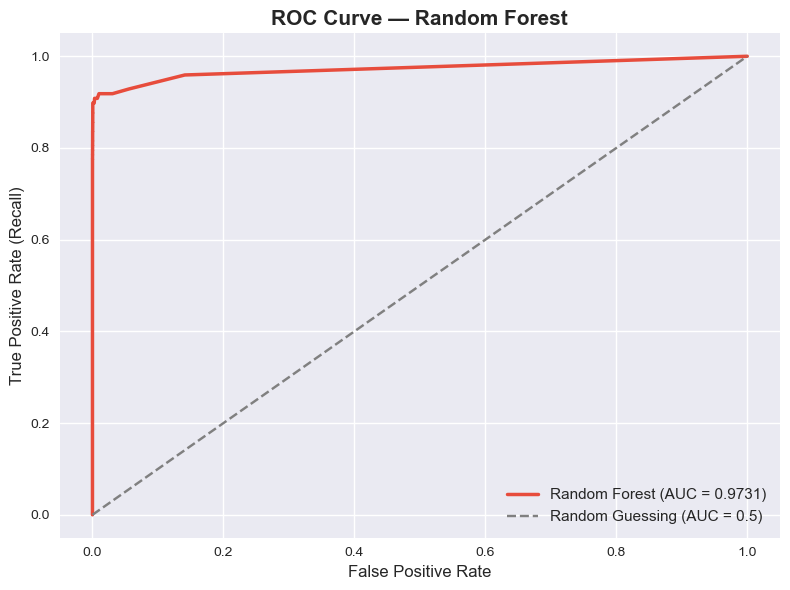

🎯 AUC Score: 0.9731


In [33]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities (continuous 0–1 score, not binary 0/1)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Compute ROC curve points across all thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

# Compute the overall AUC score
auc_score = roc_auc_score(y_test, y_prob_rf)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', linewidth=2.5, 
         label=f'Random Forest (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', 
         label='Random Guessing (AUC = 0.5)')

plt.title('ROC Curve — Random Forest', 
          fontsize=15, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

print(f"🎯 AUC Score: {auc_score:.4f}")

# Review Above work

In [4]:
import pandas as pd
import numpy as np


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [6]:
# Data Load
df = pd.read_csv("C:\\Users\\hp\\Desktop\\Project_CSV(ML)\\creditcard.csv")

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
# Feature Scaling — StandardScaler on Amount and Time
amount_scaler = StandardScaler()
time_scaler = StandardScaler()
X_train['Amount'] = amount_scaler.fit_transform(X_train[['Amount']])
X_train['Time'] = time_scaler.fit_transform(X_train[['Time']])
X_test['Amount'] = amount_scaler.transform(X_test[['Amount']])
X_test['Time'] = time_scaler.transform(X_test[['Time']])

In [8]:
# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [9]:
# Build Random Forest with optimised parameters
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=50,        # Reduced for faster training in this pipeline review
    class_weight='balanced',
    max_depth=15,           # Limit tree depth to prevent overfitting
    n_jobs=-1
)

In [10]:
rf_model.fit(X_train_smote, y_train_smote)

print("✅ Setup Complete!")

✅ Setup Complete!


In [11]:
import joblib
import os

os.makedirs('models', exist_ok=True)


In [12]:
joblib.dump(rf_model, 'models/fraud_model.pkl')
joblib.dump(amount_scaler, 'models/amount_scaler.pkl')
joblib.dump(time_scaler, 'models/time_scaler.pkl')
joblib.dump(list(X_train.columns), 'models/feature_names.pkl')

print("✅ Saved: fraud_model.pkl")
print("✅ Saved: amount_scaler.pkl")
print("✅ Saved: time_scaler.pkl")
print("✅ Saved: feature_names.pkl")

print("\n📁 Files in models folder:")
for file in os.listdir('models'):
    size = os.path.getsize(f'models/{file}')
    print(f"   {file} — {size/1024:.1f} KB")

✅ Saved: fraud_model.pkl
✅ Saved: amount_scaler.pkl
✅ Saved: time_scaler.pkl
✅ Saved: feature_names.pkl

📁 Files in models folder:
   amount_scaler.pkl — 0.9 KB
   feature_names.pkl — 0.2 KB
   fraud_model.pkl — 5202.6 KB
   time_scaler.pkl — 0.9 KB


# Hyper Parameter Tuning

In [13]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=5,           # Test 5 random combinations
    scoring='recall',   # Optimise for Recall (catching fraud is the priority)
    cv=3,               # 3-fold cross-validation
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [14]:
# Use a 50,000-row sample for faster tuning while keeping a representative distribution
X_sample = X_train_smote.sample(50000, random_state=42)
y_sample = y_train_smote.loc[X_sample.index]

random_search.fit(X_sample, y_sample)

print("✅ Best Parameters:")
print(random_search.best_params_)
print(f"\n🎯 Best Recall: {random_search.best_score_:.4f}")
print(f"\n📊 All Results:")
results = pd.DataFrame(random_search.cv_results_)
print(results[['params', 'mean_test_score']].sort_values(
      'mean_test_score', ascending=False))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
✅ Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 15}

🎯 Best Recall: 0.9947

📊 All Results:
                                              params  mean_test_score
3  {'n_estimators': 100, 'min_samples_split': 5, ...         0.994684
0  {'n_estimators': 50, 'min_samples_split': 5, '...         0.994605
1  {'n_estimators': 50, 'min_samples_split': 2, '...         0.980257
4  {'n_estimators': 50, 'min_samples_split': 2, '...         0.980057
2  {'n_estimators': 100, 'min_samples_split': 5, ...         0.978898


In [16]:
# Build the final model using the best hyperparameters found above
rf_final = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=5,
    min_samples_leaf=1,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [17]:
# Train on the FULL SMOTE dataset (not just the sample used for tuning)
rf_final.fit(X_train_smote, y_train_smote)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_split=5, n_jobs=-1, random_state=42)

In [18]:
# Evaluate the tuned model on the original test set
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_final = rf_final.predict(X_test)
y_prob_final = rf_final.predict_proba(X_test)[:, 1]

In [19]:
print("📊 Final Model Results:")
print(classification_report(y_test, y_pred_final,
      target_names=['Genuine', 'Fraud']))

print(f"🎯 ROC-AUC: {roc_auc_score(y_test, y_prob_final):.4f}")

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
avg_fraud = df[df['Class']==1]['Amount'].mean()
print(f"\n✅ Fraud Caught: {tp}")
print(f"❌ Fraud Missed: {fn}")
print(f"💰 Money Saved: €{tp * avg_fraud:,.2f}")
print(f"💸 Money Lost:  €{fn * avg_fraud:,.2f}")

📊 Final Model Results:
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56864
       Fraud       0.65      0.85      0.73        98

    accuracy                           1.00     56962
   macro avg       0.82      0.92      0.87     56962
weighted avg       1.00      1.00      1.00     56962

🎯 ROC-AUC: 0.9811

✅ Fraud Caught: 83
❌ Fraud Missed: 15
💰 Money Saved: €10,143.54
💸 Money Lost:  €1,833.17


In [20]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# Tuned model save karo
joblib.dump(rf_final, 'models/fraud_model_tuned.pkl')

print("✅ Tuned model saved: fraud_model_tuned.pkl")

for file in os.listdir('models'):
    size = os.path.getsize(f'models/{file}')
    print(f"   {file} — {size/1024:.1f} KB")

✅ Tuned model saved: fraud_model_tuned.pkl
   amount_scaler.pkl — 0.9 KB
   feature_names.pkl — 0.2 KB
   fraud_model.pkl — 5202.6 KB
   fraud_model_tuned.pkl — 10275.9 KB
   time_scaler.pkl — 0.9 KB


# Shap Analysis

In [21]:
import shap

# Create a TreeExplainer for the Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Compute SHAP values on a small test sample (500 rows) for speed
# Running on the full test set (56,962 rows) would be very slow
X_test_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print("✅ SHAP Values Calculated!")
print(f"Shape: {shap_values.shape}")

✅ SHAP Values Calculated!
Shape: (500, 30, 2)


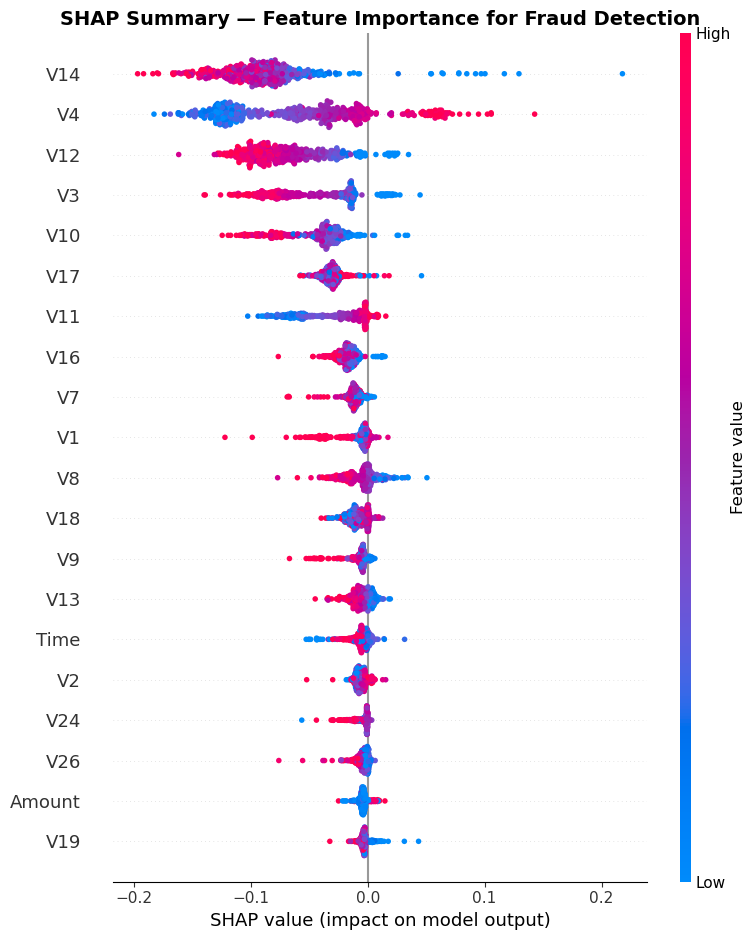

In [23]:
# Extract SHAP values for the FRAUD class only (index 1)
shap_values_fraud = shap_values[:, :, 1]

# Summary plot — the most informative SHAP visualisation
# Each dot = one transaction; colour = feature value; x-axis = impact on fraud prediction
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_fraud, X_test_sample, 
                   show=False)
plt.title('SHAP Summary — Feature Importance for Fraud Detection',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

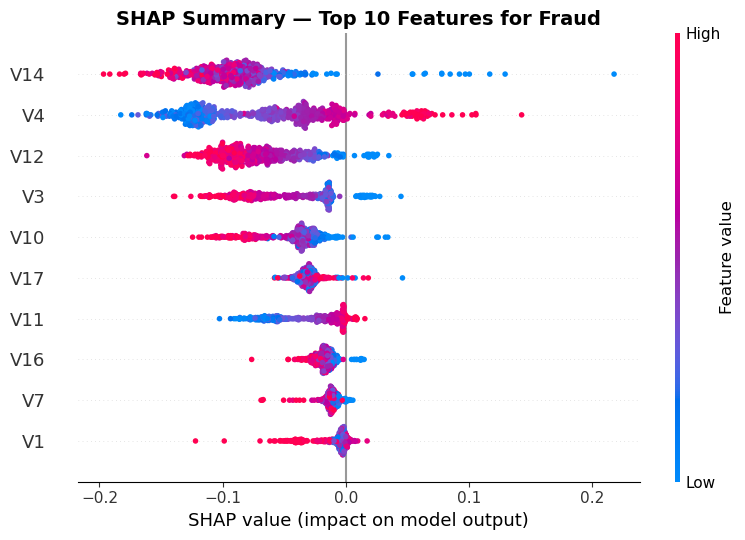

In [24]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_fraud, X_test_sample, 
                   max_display=10,    # Show only the TOP 10 most impactful features
                   show=False)
plt.title('SHAP Summary — Top 10 Features for Fraud',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()